In [1]:
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import snapatac2 as snap
import numpy as np
import pandas as pd
import os
import scanpy.external as sce
import seaborn as sns
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import chi2
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict,GroupKFold,KFold
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score
from xgboost import XGBClassifier,XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
from collections import defaultdict
import glob
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple


In [2]:
color_palettes = {
    "base_region": {
        "PFC": "#8c564b",
        "HPF": "#15A698",
        "AMY": "#ff7f0e",
        "STR": "#e377c2",
        "TH": "#bcbd22",
        "HY": "#d62728",
        "MB": "#9467bd"
    },
    "base_nt": {
        "Glut": "#FFC000",
        "GABA": "#00B050",
        "Dopa": "#ff7f0e",
        "Chol": "#1f77b4",
        "Hist": "#aa40fc",
        "Sero": "#e377c2",
        "NN": "#8c564b"
    },
    "base_class": {
        "Glut": "#FFC000",
        "GABA": "#00B050",
        "Dopa": "#ff7f0e",
        "Chol": "#1f77b4",
        "Hist": "#aa40fc",
        "Sero": "#e377c2",
        "Other N": "#D3D3D3",
        "Other_N": "#D3D3D3",
        "OPC": "#8194AC",
        "Oligo": "#7030A0",
        "Astrocyte": "#17becf",
        "Microglia": "#ff9896",
        "Epen": "#FF7F50",
        "Vascular": "#5F8BB2",
        "Immune": "#EF6347"
    },
    "base_sex": {
        "M": "#55A0FB",
        "F": "#FFA0A0"
    },
    "base_model": {
        # 这里保留原结构，但注意pair_or_not条件
        "pair_condition": {
            "pair": {
                "CUSUS F": "#A5D86E",
                "CURES F": "#F6B1C3",
                "CUSUS M": "#00B0F0",
                "CURES M": "#E63CE6",
                "CSSUS M": "#2B6CB8",
                "CSRES M": "#BD551C",
                "SUS": "#46A6B2",
                "RES": "#DB6B94",
                "CUMS": "#A88ED3",
                "CSDS": "#7A4A6F",
                "F_CUMS": "#E8A5CB",
                "M_CUMS": "#63A2E1",
                "M_CSDS": "#3F6DA1",
                "F_SUS": "#9BC2C8",
                "F_RES": "#EAA6B5",
                "M_SUS": "#239FBF",
                "M_RES": "#9A56C2",
                "CUMS_SUS": "#77A6C9",
                "CUMS_RES": "#C694C9",
                "CSDS_SUS": "#4B6F8F",
                "CSDS_RES": "#A05B7F"
            },
            "no_pair": {
                "CUSUS F": "#A5D86E",
                "CUSUS M": "#00B0F0",
                "CSSUS M": "#2B6CB8",
                "CURES F": "#F6B1C3",
                "CURES M": "#E63CE6",
                "CSRES M": "#BD551C",
                "SUS": "#46A6B2",
                "RES": "#DB6B94",
                "CUMS": "#A88ED3",
                "CSDS": "#7A4F6F",
                "F_CUMS": "#E8A5CB",
                "M_CUMS": "#63A2E1",
                "M_CSDS": "#3F6DA1"
            }
        }
    }
}

In [3]:
df_dmr_cums_l1_wide = pd.read_csv('/data2st1/junyi/output/atac1112/dmr_gene_component_class_l1_wide.csv')

In [4]:
id_cols_l1 = ['dmr', 'Gene', 'Region', 'Direction', 'Model', 'gene_diff','dmr_diff', 'Direction_m']
class_cols_l1 = ['Astrocyte',
 'Chol',
 'Dopa',
 'Epen',
 'GABA',
 'Glut',
 'Microglia',
 'OPC',
 'Oligo',
 'Sero',
 'Vascular']

In [25]:
    region_order = [value for value in df_dmr_cums_l1_selected['Region'].dropna().unique() if value in plot_df['Region'].values]


In [32]:
df_dmr_cums_l1_selected

,dmr,Gene,Region,Direction,Model,gene_diff,dmr_diff,Direction_m,Astrocyte,Chol,...,Vascular,Dominant Class,Dominant Class Proportion,DEG Class Count,N-Class DEGs,Neuron DEGs,chr,start,end,chr_int
0,5hmC|CG_1:6518139-6518219,Rb1cc1,PFC,Up,CSSUS M,0.136422,0.052118,5hmC|CGUp_distal,0.0,0.0,...,0.0,GABA,0.176656,2,1,2,1,6518139,6518219,1
2,5hmC|CG_1:9831774-9831836,Sgk3,PFC,Up,CSSUS M,0.075605,0.210679,5hmC|CGUp_genebody,0.0,0.0,...,0.0,Glut,0.121188,1,1,1,1,9831774,9831836,1
3,5hmC|CG_1:9930765-9930840,Vxn,PFC,Down,CUSUS F,-0.098423,-0.155538,5hmC|CGDown_distal,0.0,0.0,...,0.0,Glut,0.142162,1,1,1,1,9930765,9930840,1
4,5hmC|CG_1:9984656-9984724,Vxn,PFC,Down,CUSUS F,-0.098423,-0.090386,5hmC|CGDown_distal,0.0,0.0,...,0.0,Glut,0.142162,1,1,1,1,9984656,9984724,1
7,5hmC|CG_1:12746113-12746209,Ncoa2,TH,Up,CUSUS F,0.104328,0.135812,5hmC|CGUp_distal,0.0,0.0,...,0.0,GABA,0.171671,2,1,2,1,12746113,12746209,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14274,5hmC|CG_X:169996883-169998185,Gm15261,STR,Down,CSSUS M,-0.059736,-0.306236,5hmC|CGDown_distal,0.0,0.0,...,0.0,GABA,0.091422,1,1,1,X,169996883,169998185,23
14275,5hmC|CG_X:169996883-169998185,Gm15261,AMY,Up,CUSUS F,0.154863,0.129728,5hmC|CGUp_distal,0.0,0.0,...,0.0,GABA,0.259378,2,1,2,X,169996883,169998185,23
14276,5hmC|CG_X:170010636-170010682,Gm15261,STR,Down,CSSUS M,-0.059736,-0.283100,5hmC|CGDown_promoter,0.0,0.0,...,0.0,GABA,0.091422,1,1,1,X,170010636,170010682,23
14277,5hmC|CG_X:170010636-170010682,Gm15261,AMY,Up,CUSUS F,0.154863,0.173433,5hmC|CGUp_promoter,0.0,0.0,...,0.0,GABA,0.259378,2,1,2,X,170010636,170010682,23


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexH

Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm
Starting plotting..
Starting calculating row orders..
Reordering rows..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexH

Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm


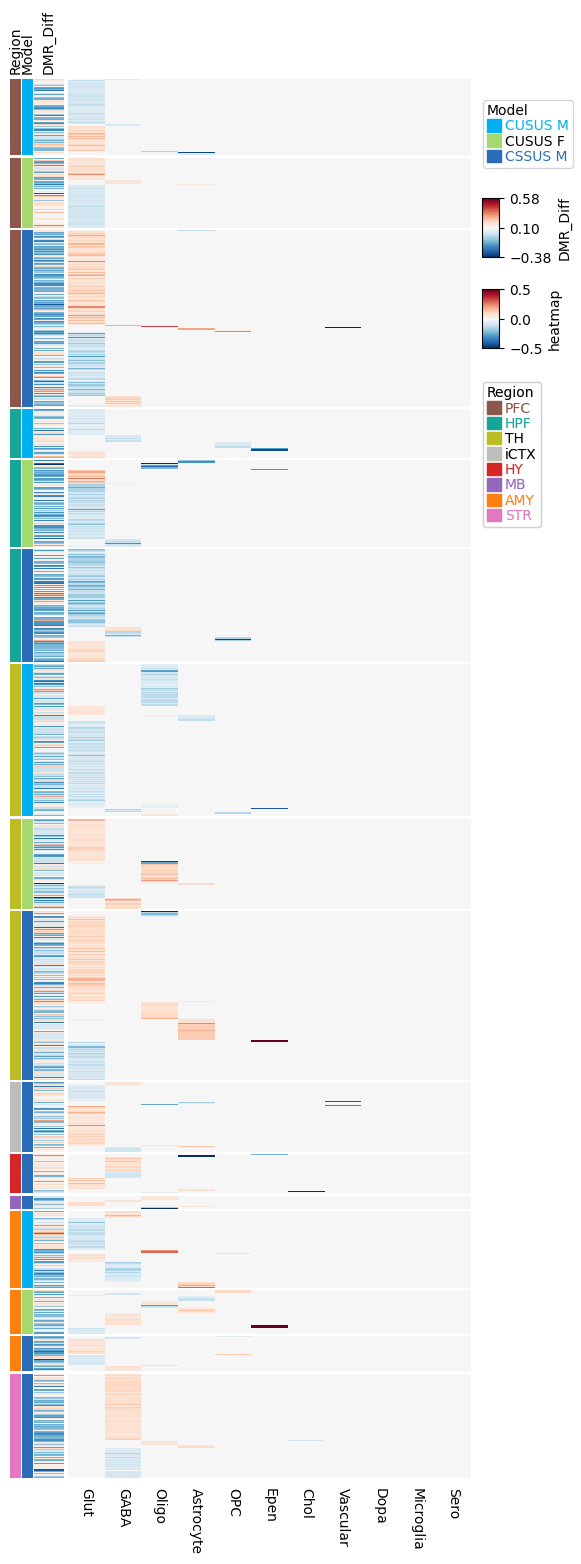

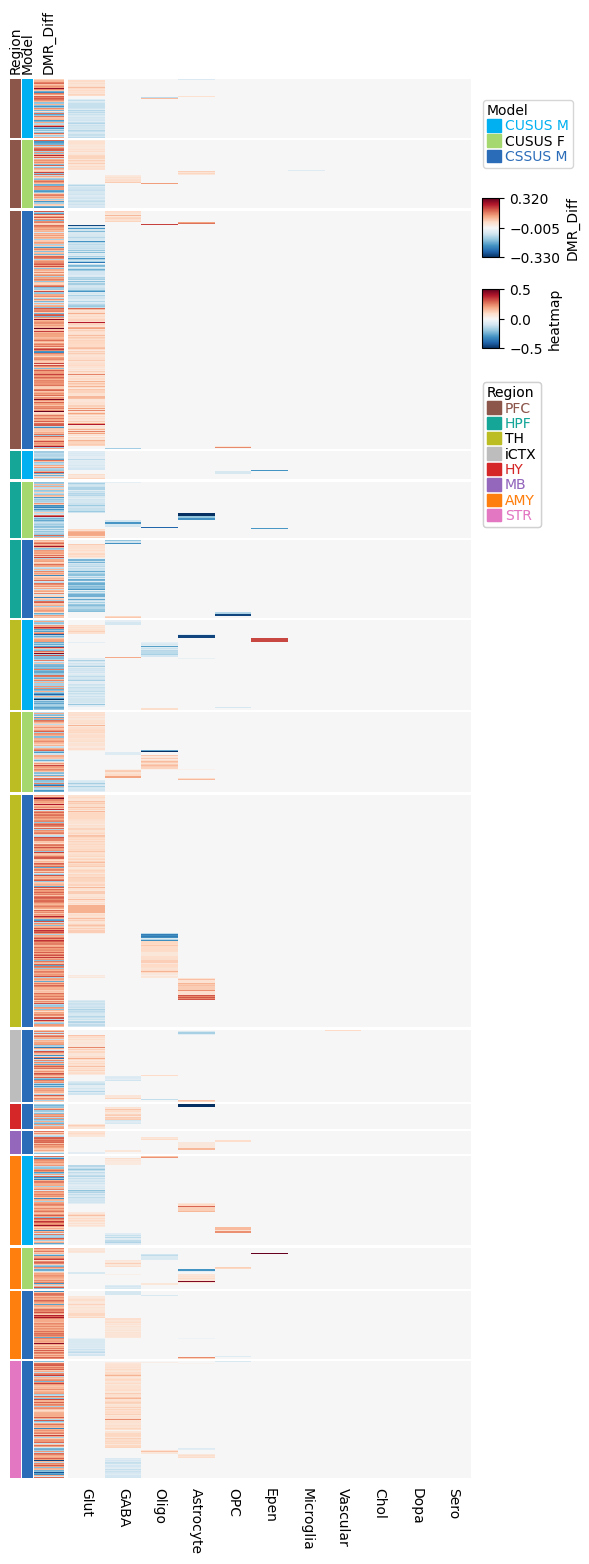

In [33]:
for modification in ['5mC', '5hmC',]:
    df_dmr_cums_l1_selected = df_dmr_cums_l1_wide[df_dmr_cums_l1_wide.dmr.str.contains(modification)]
    df_dmr_cums_l1_selected = df_dmr_cums_l1_selected[df_dmr_cums_l1_selected['DEG Class Count']==1]

    plot_df = df_dmr_cums_l1_selected.loc[:, ['dmr', 'Model', 'Region', 'dmr_diff'] + class_cols_l1].copy()
    plot_df['original_order'] = np.arange(len(plot_df))
    plot_df['row_id'] = (
        plot_df['dmr'].astype(str)
        + ' | ' + plot_df['Model'].astype(str)
        + ' | ' + plot_df['Region'].astype(str)
    )

    plot_df = plot_df.groupby(['row_id', 'dmr', 'Model', 'Region'], as_index=False, sort=False).agg(
        {
            **{column: 'mean' for column in class_cols_l1},
            'dmr_diff': 'mean',
            'original_order': 'min',
        }
    )

    preferred_model_order = ['CUSUS M', 'CUSUS F', 'CSSUS M']
    preferred_model_order
    model_order = [value for value in preferred_model_order if value in plot_df['Model'].values]
    model_order += [
        value for value in df_dmr_cums_l1_selected['Model'].dropna().unique()
        if value in plot_df['Model'].values and value not in model_order
    ]
    region_order = [value for value in df_dmr_cums_l1_wide['Region'].dropna().unique() if value in plot_df['Region'].values]

    heatmap_df = plot_df.set_index('row_id')[class_cols_l1].copy()
    column_order = heatmap_df.ne(0).sum(axis=0).sort_values(ascending=False).index
    heatmap_df = heatmap_df.loc[:, column_order]
    heatmap_df.clip(lower=-0.5, upper=0.5, inplace=True)
    row_meta = plot_df.set_index('row_id')[['dmr', 'Model', 'Region', 'dmr_diff']].copy()

    model_palette_source = color_palettes['base_model']['pair_condition']['no_pair']
    region_palette_source = color_palettes['base_region']
    model_colors = {
        value: model_palette_source.get(value, '#808080')
        for value in model_order
    }
    region_colors = {
        value: region_palette_source.get(value, '#bdbdbd')
        for value in region_order
    }

    left_ha = HeatmapAnnotation(
        Region=anno_simple(row_meta['Region'], colors=region_colors, legend=True),
        Model=anno_simple(row_meta['Model'], colors=model_colors, legend=True),
        DMR_Diff=anno_simple(
            row_meta['dmr_diff'],
            cmap='RdBu_r',
            legend=True,
            height=8,
        ),
        axis=0,
    )
    split_categories = [
        f'{region} | {model}'
        for region in region_order
        for model in model_order
        if ((plot_df['Region'].astype(str) + ' | ' + plot_df['Model'].astype(str)) == f'{region} | {model}').any()
    ]
    row_split = pd.Series(
        pd.Categorical(
            plot_df['Region'].astype(str) + ' | ' + plot_df['Model'].astype(str),
            categories=split_categories,
            ordered=True,
        ),
        index=heatmap_df.index,
        name='Region | Model',
    )
    plt.figure(figsize=(6, 16))

    ClusterMapPlotter(
        data=heatmap_df,
        left_annotation=left_ha,
        row_split=row_split,
        row_split_order=split_categories,
        row_cluster=True,
        col_cluster=False,
        show_rownames=False,
        show_colnames=True,
        cmap='RdBu_r',
        center=0,
        rasterized=True,
    )
    plt.savefig(
        f'/data2st1/junyi/output/atac1112/dmr_gene_heatmap_l1_{modification}.pdf'    )

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm


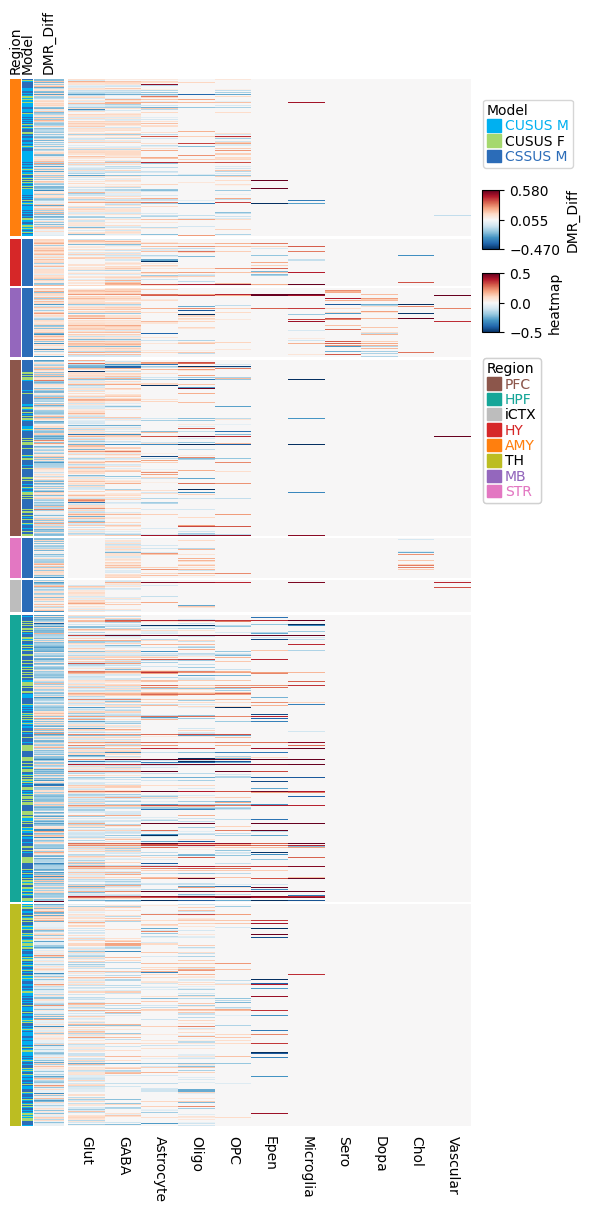

In [573]:
plt.figure(figsize=(6, 12))

ClusterMapPlotter(
    data=heatmap_df,
    left_annotation=left_ha,
    row_split=row_meta['Region'],
    row_cluster=False,
    col_cluster=False,
    show_rownames=False,
    show_colnames=True,
    cmap='RdBu_r',
    center=0,
    rasterized=True,
 )
plt.show()

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 19.051388888888887 mm


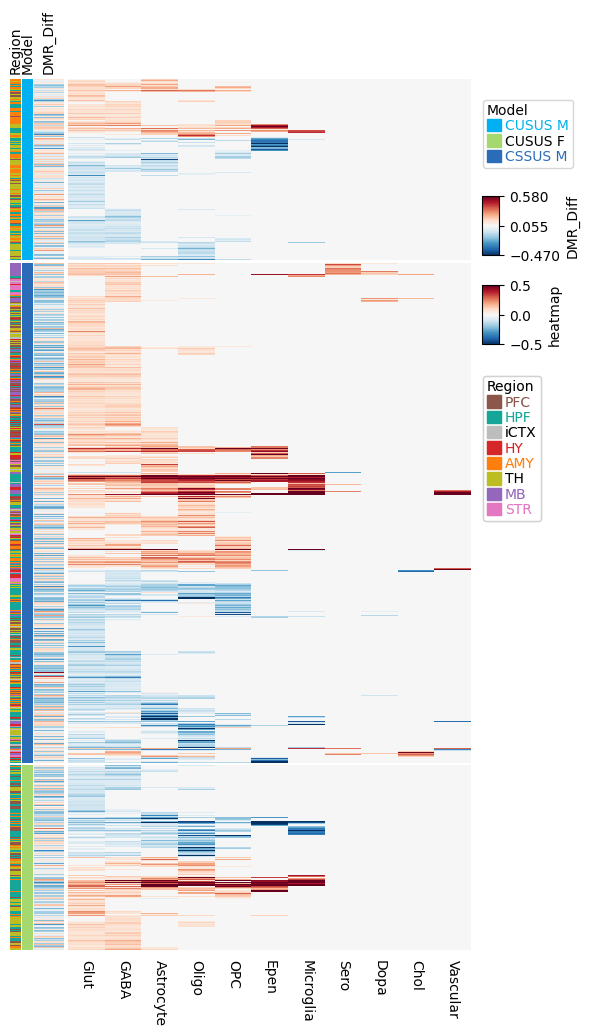

In [530]:
plt.figure(figsize=(6, 10))

ClusterMapPlotter(
    data=heatmap_df,
    left_annotation=left_ha,
    row_split=row_meta['Model'],
    row_cluster=True,
    col_cluster=False,
    show_rownames=False,
    show_colnames=True,
    cmap='RdBu_r',
    center=0,
    rasterized=True,
 )
plt.show()

In [363]:
# use XGBoost regressor to predict gene_diff using the class columns as features
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Prepare the data
df_dmr_5MC = df_dmr_cums_l1_wide[df_dmr_cums_l1_wide['dmr'].str.contains('5mC|CH')].copy()
df_dmr_5MC['gene_diff_numeric'] = pd.to_numeric(
    df_dmr_5MC['gene_diff'].astype(str).str.strip('[]'),
    errors='coerce',
    )
df_dmr_5MC = df_dmr_5MC.dropna(subset=['gene_diff_numeric'])

X = df_dmr_5MC.loc[:, class_cols_l1].astype(float).values
y = df_dmr_5MC['gene_diff_numeric'].astype(float).to_numpy()

X_train = X[:int(0.8 * len(X))]
y_train = y[:int(0.8 * len(y))]
X_test = X[int(0.8 * len(X)): ]
y_test = y[int(0.8 * len(y)): ]

# Fit the regression model
model = XGBRegressor(base_score=float(np.mean(y_train)))
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R-squared: {r2:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R-squared: 0.9215
Mean Squared Error: 0.0010


In [364]:
df_dmr_5MC

,dmr,Gene,Region,Direction,Model,gene_diff,dmr_diff,Direction_m,Astrocyte,Chol,...,OPC,Oligo,Sero,Vascular,Dominant Class,Dominant Class Proportion,DEG Class Count,N-Class DEGs,Neuron DEGs,gene_diff_numeric
6773,5mC|CG_10:105261169-105261219,Tmtc2,TH,Down,CUSUS M,-0.070202,0.173257,5mC|CGUp_genebody,0.00000,0.0,...,0.000000,-0.082006,0.000000,0.0,Oligo,0.082006,2,2,1,-0.070202
6774,5mC|CG_10:105370624-105370709,Mettl25,PFC,Up,CSSUS M,0.058638,-0.160546,5mC|CGDown_distal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,Glut,0.071829,2,1,2,0.058638
6775,5mC|CG_10:105370624-105370709,Tmtc2,PFC,Up,CSSUS M,0.059815,-0.160546,5mC|CGDown_distal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,Glut,0.051238,1,1,1,0.059815
6776,5mC|CG_10:105510147-105510334,Ppfia2,PFC,Up,CUSUS F,0.119236,0.148590,5mC|CGUp_cdistal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,GABA,0.097809,2,1,2,0.119236
6777,5mC|CG_10:105741367-105741666,Ppfia2,AMY,Down,CUSUS M,-0.183444,0.160449,5mC|CGUp_cdistal,0.00000,0.0,...,-0.098923,0.000000,0.000000,0.0,GABA,0.114236,3,3,2,-0.183444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14275,5mC|CH_X:70138195-70138691,Ids,AMY,Down,CSSUS M,-0.066290,0.019039,5mC|CHUp_distal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,GABA,0.098707,2,1,2,-0.066290
14276,5mC|CH_X:72804643-72804741,Ssr4,MB,Down,CSSUS M,-0.059749,0.011360,5mC|CHUp_cdistal,0.00000,0.0,...,0.000000,0.000000,-0.275793,0.0,Sero,0.275793,3,1,3,-0.059749
14277,5mC|CH_X:72986042-72986249,L1cam,TH,Up,CSSUS M,0.077461,0.011369,5mC|CHUp_cdistal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,Glut,0.125135,1,1,1,0.077461
14278,5mC|CH_X:73094280-73094426,L1cam,TH,Up,CSSUS M,0.077461,0.012075,5mC|CHUp_cdistal,0.00000,0.0,...,0.000000,0.000000,0.000000,0.0,Glut,0.125135,1,1,1,0.077461


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

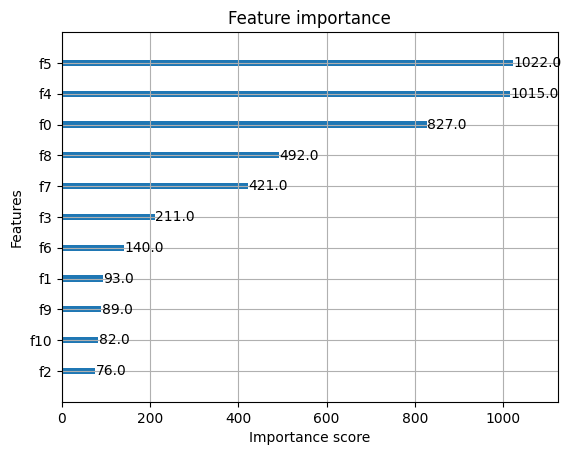

In [351]:
import xgboost

xgboost.plot_importance(model)


In [359]:
X_test[1]

array([0.        , 0.        , 0.        , 0.        , 0.12500498,
       0.08646223, 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [ ]:
df_dmr_cums_tab_wide.drop_duplicates(subset=['dmr','Region','Model']).to_csv('/data2st1/junyi/output/atac1112/dmr_gene_component_class_wide_distinct.csv')

In [ ]:
df_dmr_cums_tab_N = df_dmr_cums_tab[df_dmr_cums_tab['Neurotransmitter']!='NN']

In [ ]:
df_deg.groupby(['Gene','Region','']).agg({'Region subclass': 'nunique'}).reset_index()

In [ ]:
df_deg.groupby(['Region','Class']).agg({'Region subclass': 'nunique'}).reset_index()

In [ ]:
df_dmr_cums_tab_N

In [ ]:
df_dmr_cums_tab_N.sort_values(by=['gene_x','Region subclass'], ascending=False).to_csv('/data2st1/junyi/output/atac1112/dmrgene_CUMS.csv', index=False)

In [ ]:
region = 'PFC'
typedict = {'5mC': 'm', '5hmC': 'h'}
condition = 'MW'
motif = 'CG'
methtype = '5hmC'


In [ ]:
sum_sigmethylation = []
sum_sigatac = []
sum_names = []
for region in ['AMY', 'HIP', 'PFC']:
    for condition in ['MW', 'MC']:
        for methtype in ['5mC', '5hmC']:
            meth_tracks = glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/*{condition}*{region}.6mA_5mC5hmC.{motif}.pileup.{typedict[methtype]}.bigwig')
            # 打开 BigWig 文件
            methlist = []
            for meth_track in meth_tracks:
                try:
                    meth = pyBigWig.open(meth_track)
                    methlist.append(meth)
                except Exception as e:
                    print(f"Error opening {meth_track}: {e}")

            atac = pyBigWig.open(f"/data2st2/junyi/output/atac1112/tobiasbam/BULK/corrected/{region}_{condition}_track.bw")
            df_hip=df_dmr_selected[df_dmr_selected['region']==region]
            # for each row in df_hip, extract the mean signal from the BigWig file for the corresponding region
            signals = []
            corrs = []
            for index, row in df_hip.iterrows():
                try:
                    chrom = row['chr']
                    start = row['start_expanded']
                    end = row['end_expanded']


                    # get the average signal from the BigWig file for the region
                    meth_signals = []
                    for meth in methlist:
                        meth_tmp = meth.values(chrom, start, end)
                        meth_tmp_sig = np.nan_to_num(meth_tmp)
                        meth_signals.append(meth_tmp_sig)
                    meth_signal = np.mean(meth_signals,axis=0)


                    atac_signal = atac.values("chr"+chrom, start, end)

                    #fill nan with 0
                    atac_signal = np.nan_to_num(atac_signal)

                    seq = get_sequence("chr"+chrom, start, end-1, genome)
                            # REMOVE the position that the position is not C
                    seq_array = np.array(list(seq.upper()))
                    is_c = (seq_array == 'C')
                    is_g = (seq_array == 'G')
                    is_cg = is_c | is_g

                    meth_signal_clean = meth_signal[is_cg]
                    atac_signal_clean = atac_signal[is_cg]

                    sum_sigmethylation.append(meth_signal_clean.mean())
                    sum_sigatac.append(atac_signal.mean())
                    sum_names.append(f"{region}_{condition}_{methtype}")

                    # calculate the correlation between meth_signal and atac_signal
                    if len(meth_signal_clean) > 1 and len(atac_signal_clean) > 1:
                        corr, _ = pearsonr(meth_signal_clean, atac_signal_clean)
                    else:
                        corr = np.nan
                except Exception as e:
                    corr = np.nan
                corrs.append(corr)
            plt.hist(corrs, bins=50,alpha=0.5,label=f'{region}_{condition}_{methtype}')
            plt.legend()
        plt.savefig(f'figures/{region}_{condition}_{methtype}_correlation_histogram.png')
        plt.clf()
        print(f"{region}_{condition}_{methtype}: mean corr = {np.nanmean(corrs):.4f}, median corr = {np.nanmedian(corrs):.4f}")


In [ ]:
import pyBigWig
import numpy as np
from scipy.stats import pearsonr, spearmanr

def calculate_chrom_correlation(bw_file1, bw_file2, chrom1, chrom2, bin_size=1000, corr_type='pearson'):
    """
    计算两个染色体 BigWig 信号在给定 bin 大小下的相关性
    
    参数：
    bw_file1, bw_file2: BigWig 文件路径
    chrom1, chrom2: 染色体名称，如 'chr1', 'chr2'
    bin_size: bin 大小（bp），默认 1000
    corr_type: 相关性类型，'pearson' 或 'spearman'
    """
    # 1. 打开 BigWig 文件
    bw1 = pyBigWig.open(bw_file1)
    bw2 = pyBigWig.open(bw_file2)
    
    # 2. 获取染色体长度
    chrom_len1 = bw1.chroms()[chrom1]
    chrom_len2 = bw2.chroms()[chrom2]
    
    # 3. 计算 bin 数量（取两者中较短的长度）
    n_bins = min(chrom_len1, chrom_len2) // bin_size
    
    # 4. 创建 bin 边界
    bins = [(i * bin_size, (i + 1) * bin_size) for i in range(n_bins)]
    
    # 5. 提取每个 bin 的信号（平均值）
    signal1 = []
    signal2 = []
    for start, end in bins:
        # 注意：确保 end 不超过染色体长度
        end = min(end, chrom_len1, chrom_len2)
        s1 = bw1.stats(chrom1, start, end)[0] or 0
        s2 = bw2.stats(chrom2, start, end)[0] or 0
        signal1.append(s1)
        signal2.append(s2)
    
    # 6. 计算相关性
    signal1 = np.array(signal1)
    signal2 = np.array(signal2)
    
    if corr_type == 'pearson':
        corr, pval = pearsonr(signal1, signal2)
    elif corr_type == 'spearman':
        corr, pval = spearmanr(signal1, signal2)
    else:
        raise ValueError("corr_type 必须是 'pearson' 或 'spearman'")
    
    bw1.close()
    bw2.close()
    
    return corr, pval, n_bins, signal1, signal2

# 使用示例
bw1_path = "your_file1.bw"
bw2_path = "your_file2.bw"
chrom1 = "chr1"
chrom2 = "chr2"

corr, pval, n_bins, s1, s2 = calculate_chrom_correlation(
    bw1_path, bw2_path, chrom1, chrom2, bin_size=1000, corr_type='pearson'
)
print(f"染色体 {chrom1} 与 {chrom2} 在 {n_bins} 个 bins 下的 Pearson 相关系数: {corr:.4f}, p-value: {pval:.4e}")

In [ ]:
corr_df = pd.DataFrame({
    'sample': sum_names,
    'mean_methylation': sum_sigmethylation,
    'mean_atac': sum_sigatac
})

In [ ]:
corr_df

In [ ]:
import pyBigWig
from scipy.stats import spearmanr

for region in ['AMY','HIP','PFC']:
    for condition in ['MW', 'MC']:
        files = glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/*{condition}*{region}.6mA_5mC5hmC.CG.pileup.m.bigwig')
        for f in files:
            print(f)
            # 打开 BigWig 文件
            meth = pyBigWig.open(f)
            meth1 = f.replace('.m.bigwig', '.h.bigwig')
            meth2 = pyBigWig.open(meth1)
            df_hip=df_dmr_selected[df_dmr_selected['region']==region]
            df_hip=df_hip[df_hip['motif']=='CG']
            df_hip=df_hip[df_hip['comparision'].str.contains('MC')]
            # for each row in df_hip, extract the mean signal from the BigWig file for the corresponding region
            corrs = []
            seqs = []
            sig1 = []
            sig2 = []
            for index, row in df_hip.iterrows():
                try:
                    chrom = row['chr']
                    start = row['start_expanded']
                    end = row['end_expanded']
                    meth_signal = meth.values(chrom, start, end)
                    meth2_signal = meth2.values(chrom, start, end)
                    

                    #fill nan with 0
                    meth_signal = np.nan_to_num(meth_signal)
                    meth2_signal = np.nan_to_num(meth2_signal)

                    sig1.append(meth_signal)
                    sig2.append(meth2_signal)

                    seq = genome["chr"+chrom][start:end].seq
                    seqs.append(seq)


                    # REMOVE the position that the position is not C
                    seq_array = np.array(list(seq.upper()))
                    is_c = (seq_array == 'C')
                    is_g = (seq_array == 'G')
                    is_cg = is_c | is_g

                    meth_signal_clean = meth_signal[is_cg]
                    meth2_signal_clean = meth2_signal[is_cg]

                    # calculate the correlation between meth_signal and meth2_signal
                    if len(meth_signal_clean) > 1 and len(meth2_signal_clean) > 1:
                        if sum(meth_signal_clean) > 0 and sum(meth2_signal_clean) > 0:
                            corr, _ = pearsonr(meth_signal_clean, meth2_signal_clean)
                    else:
                        corr = 0
                except Exception as e:
                    corr = 0
                corrs.append(corr)
            plt.hist(corrs, bins=50)
            plt.savefig(f'figures/{os.path.basename(f)[:9]}_5mC_5hmC_correlation_histogram.png')
            plt.clf()

In [ ]:
meth_signal_clean

In [ ]:
meth2_signal_clean

In [ ]:
DF_CG=pd.DataFrame({
    'seq': seq_array,
    'meth_signal': meth_signal,
    'meth2_signal': meth2_signal
})

In [ ]:
DF_CG

In [ ]:
pearsonr(meth_signal_clean, meth2_signal_clean)

In [ ]:
seq_array = np.array(list(seq.upper()))
is_c = (seq_array == 'C')

meth_signal_clean = meth_signal[is_c]
#open_signal_clean = open_signal[is_c]


In [ ]:
DF_CG

In [ ]:
seq = genome["chr"+chrom][start:end].seq

In [ ]:
seq_array = np.array(list(seq.upper()))
seq_array


In [ ]:
is_c = (seq_array == 'C')

meth_signal_clean = meth_signal[is_c]
meth2_signal_clean = meth2_signal[is_c]


In [ ]:
meth_signal

In [ ]:
meth_signal_clean

In [ ]:
meth2_signal_clean

In [ ]:
def group_chromosomes(df_merged_region):
    chr_counts = df_merged_region['chr'].value_counts()

    # 2) 设定目标 group size（≈ 最大 chr）
    target_size = chr_counts.max()

    # 3) 初始化
    groups = defaultdict(list)      # group_id -> list of chrs
    group_sizes = defaultdict(int)  # group_id -> total region count

    # 4) 贪心分配（chr 从大到小）
    for chr_name, count in chr_counts.sort_values(ascending=False).items():
        # 找当前 size 最小的 group
        if len(group_sizes) == 0:
            gid = 0
        else:
            gid = min(group_sizes, key=lambda k: group_sizes[k])

        # 如果这个 group 已经接近 target，新建一个
        if group_sizes[gid] + count > target_size * 1.1:
            gid = len(group_sizes)

        groups[gid].append(chr_name)
        group_sizes[gid] += count

    chrGroup = df_merged_region['chr'].map(
        {chr_name: gid for gid, chr_list in groups.items() for chr_name in chr_list}
    ).values
    return chrGroup

In [ ]:
# data preparation
pefromdict = {}

for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        df_region_mod = annodict[mod][annodict[mod]['Region'] == region].copy()
        df_region_mod_frac = pd.DataFrame()
        for condition in ['MC','MW']:
            df_tmp_frac = pd.read_csv(
                f'/data2st1/junyi/output/atac1112/subset/dmr_region_nt/{region}_{mod}_{condition}_celltype_fraction.csv',
                index_col=0
            )
            # remove _MC and MW suffix from columns
            df_tmp_frac.columns = [col.replace('_MC', '').replace('_MW', '') for col in df_tmp_frac.columns]
            df_tmp_frac['condition'] = condition
            df_region_mod_frac = pd.concat([df_region_mod_frac, df_tmp_frac], axis=0)
        df_region_mod['extended_dmr'] = (
            'chr' + df_region_mod['chr'].astype(str) + ':' +
            df_region_mod['start_expanded'].astype(str) + '-' +
            df_region_mod['end_expanded'].astype(str)
        )
        df_region_mod['id'] = df_region_mod.index
        df_region_mod = df_region_mod.set_index('extended_dmr')

        df_merged_region = pd.merge(
            df_region_mod,
            df_region_mod_frac,
            left_index=True,
            right_index=True,
            how='inner'
        )

        # binary label: 1 = hyper (diff.Methy > 0), 0 = hypo
        df_merged_region['effect_binary'] = (df_merged_region['diff.Methy'] > 0).astype(int)
        df_merged_region['effect_size'] = df_merged_region['effect_size']
        df_merged_region['pct_meth'] = df_merged_region['case1_sig']
        df_merged_region.loc[df_merged_region.condition=='MW', 'pct_meth'] = df_merged_region.loc[df_merged_region.condition=='MW', 'case2_sig']
        df_merged_region['condition_binary'] = (df_merged_region['condition']=='MC').astype(int)
        df_merged_region.drop_duplicates(subset=['chr', 'start','end','condition_binary'], inplace=True)
        df_merged_region['chr']=df_merged_region['chr'].astype(str)
        df_merged_region['chrgroup'] = group_chromosomes(df_merged_region)
        feature_cols = ['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular','condition_binary']
        X = df_merged_region.loc[:, feature_cols].values.astype(np.float32)
        #y = df_merged_region['effect_binary'].values.astype(int)
        y = df_merged_region['pct_meth'].values
        chr = df_merged_region['chr'].values.astype(str)
        
        
        pefromdict[f'{region}_{mod}'] = {
            'X': X,
            'y': y,
            'chr': chr,
            'chrgroup': df_merged_region['chrgroup'].values,
            'y_reg': df_merged_region['effect_size'].values.astype(np.float32),
            'feature_cols': feature_cols,
            'df': df_merged_region
        }


In [ ]:
# map chr to group ids


In [ ]:
df_merged_region.groupby('chr')['diff.Methy'].mean()

In [ ]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
        #cv = KFold(n_splits=10, shuffle=True, random_state=42)
        #gss = GroupShuffleSplit(n_splits=10, test_size=0.1, random_state=42)

        # XGBoost regressor
        model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=8,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        X = pefromdict[f'{region}_{mod}']['X']

        # MUST be continuous (e.g., diff.Methy)
        y = pefromdict[f'{region}_{mod}']['y'].astype(np.float32)


        # out-of-fold predictions (no leakage)
        #y_pred_oof = cross_val_predict(model, X, y, cv=cv, method="predict")
        y_pred_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        #y_pred_oof = cross_val_predict(model, X, y, cv=gss, groups=chr, method="predict")

        r2 = r2_score(y, y_pred_oof)
        rmse = root_mean_squared_error(y, y_pred_oof)
        mae = mean_absolute_error(y, y_pred_oof)

        if np.std(y) > 1e-12 and np.std(y_pred_oof) > 1e-12:
            r, p = pearsonr(y, y_pred_oof)
        else:
            r, p = np.nan, np.nan

        print(region, mod)
        print("R2:", r2)
        print("Pearson r:", r, "p:", p)
        print("RMSE:", rmse)
        print("MAE:", mae)
        print("-" * 60)

        # fit final model on all data
        model.fit(X, y)

        # in-sample predictions
        y_pred = model.predict(X)

        # update dict (keep existing df/feature_cols if already stored)
        pefromdict[f'{region}_{mod}'].update({
            'model_reg': model,
            'y_pred_oof_reg': y_pred_oof,
            'y_pred_reg': y_pred
        })


In [ ]:
pearsonr(y, y_pred)

In [ ]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:

        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5)
        X = pefromdict[f'{region}_{mod}']['X']
        y = pefromdict[f'{region}_{mod}']['y'].astype(int)

        # XGBoost classifier (binary logistic)
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        #y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        y_prob_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print(region, mod)
        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))
        print("-" * 60)

        # fit final model on all data
        model.fit(X, y)

        # in-sample probs/preds (for downstream SHAP etc.)
        y_prob = model.predict_proba(X)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        pefromdict[f'{region}_{mod}'] = {
            'model': model,
            'X': X,
            'y': y,
            'y_prob_oof': y_prob_oof,
            'y_pred_oof': y_pred_oof,
            'y_prob': y_prob,
            'y_pred': y_pred,
            'feature_cols': feature_cols,
            'df': df_merged_region
        }


df_merged_region

In [ ]:
# deconvolution
pefromdict = {}
for region in ['HIP','AMY','PFC']:
    for mod in ['5mC','5hmC']:
        df_region_mod = annodict[mod][annodict[mod]['Region']==region]
        df_region_mod_frac = pd.read_csv(f'/data2st1/junyi/output/atac1112/subset/dmr_region_nt/{region}_{mod}_celltype_fraction_filtered.csv', index_col=0)
        df_region_mod['extended_dmr'] = 'chr' + df_region_mod['chr'].astype(str) + ':' + df_region_mod['start_expanded'].astype(str) + '-' + df_region_mod['end_expanded'].astype(str)
        df_region_mod['id']=df_region_mod.index
        df_region_mod.set_index('extended_dmr', inplace=True)
        df_merged_region = pd.merge(df_region_mod, df_region_mod_frac, left_on='extended_dmr', right_index=True, how='inner')
        df_merged_region['effect_binary'] = (df_merged_region['diff.Methy'] > 0).astype(int)
        #df_merged_region = df_merged_region[df_merged_region.entropy < 1]

        X = df_merged_region.loc[:, ['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular']].values
        Y = df_merged_region.loc[:, ['effect_binary']].values


        # X: (n_samples, n_features)
        # Y: (n_samples,) or (n_samples,1) with {0,1}
        y = Y.ravel().astype(int)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


        model = GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))

        model.fit(X, Y)
        y_pred = model.predict(X)
        y_pred_binary = (y_pred >= 0.5).astype(int)
        pefromdict[f'{region}_{mod}'] = {
            'model': model,
            'X': X,
            'Y': Y,
            'y_prob_oof': y_prob_oof,
            'y_pred_oof': y_pred_oof,
            'y_pred': y_pred,
            'y_pred_binary': y_pred_binary
        }

In [ ]:
df_region_mod_frac.mean()

In [ ]:
for key in pefromdict:
    print(f"Performance for {key}:")
    model = pefromdict[key]['model']
    X = pefromdict[key]['X']
    Y = pefromdict[key]['Y']
    y_pred_binary = pefromdict[key]['y_pred_binary']
    y = Y.ravel().astype(int)
    print("Accuracy:", accuracy_score(y, y_pred_binary))
    print("F1:", f1_score(y, y_pred_binary))
    print("\n")
    cm = confusion_matrix(Y, y_pred_binary)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['hypomethylated', 'hypermethylated'], yticklabels=['hypomethylated', 'hypermethylated'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {key}')

In [ ]:
import shap

for key in pefromdict:
    print(f"SHAP values for {key}:")
    model = pefromdict[key]['model']
    X_tmp = pefromdict[key]['X']
    explainer = shap.TreeExplainer(model,feature_names=['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular'])
    shap_values = explainer.shap_values(X_tmp)
    pefromdict[key]['shap_values'] = shap_values
    pefromdict[key]['explainer'] = explainer

In [ ]:
shap_values_test = explainer(X_tmp)

In [ ]:
pefromdict[key]

In [ ]:
pefromdict[key]['X'][0],pefromdict[key]['Y'][0]

In [ ]:
shap.plots.waterfall(shap_values_test[0])

In [ ]:
from sklearn.linear_model import Ridge
# uy

model = Ridge(alpha=1.0, positive=True)
model.fit(X, Y)

beta = model.coef_
y_pred = model.predict(X)

In [ ]:
from scipy.stats import pearsonr,spearmanr
r, p = pearsonr(Y.flatten(), y_pred.flatten())
r2, p2 = spearmanr(Y.flatten(), y_pred.flatten())


In [ ]:
Y.flatten()

In [ ]:
y_pred.flatten()

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import nnls
from sklearn.model_selection import cross_val_score

# 数据准备，X 和 Y 是已经准备好的数据
# X: 特征矩阵, Y: 目标值 (delta 5hmC/5mC 或其它)

# 模型训练
model_ridge = Ridge(alpha=1.0, positive=True)
model_ridge.fit(X, Y)

model_lasso = Lasso(alpha=0.01)
model_lasso.fit(X, Y)

model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model_svr.fit(X, Y)


In [ ]:

#model_nnls = nnls(X, Y)

# 预测
ridge_pred = model_ridge.predict(X)
lasso_pred = model_lasso.predict(X)
svr_pred = model_svr.predict(X)
#nnls_pred = model_nnls[0] @ X.T  # NNLS 预测结果


In [ ]:
nnls_pred = svr_pred

In [ ]:

# 计算性能指标
mse_ridge = mean_squared_error(Y, ridge_pred)
r2_ridge = r2_score(Y, ridge_pred)

mse_nnls = mean_squared_error(Y, nnls_pred)
r2_nnls = r2_score(Y, nnls_pred)

mse_svr = mean_squared_error(Y, svr_pred)
r2_svr = r2_score(Y, svr_pred)

mse_lasso = mean_squared_error(Y, lasso_pred)
r2_lasso = r2_score(Y, lasso_pred)

print(f"Ridge MSE: {mse_ridge}, R²: {r2_ridge}")
print(f"NNLS MSE: {mse_nnls}, R²: {r2_nnls}")
print(f"SVR MSE: {mse_svr}, R²: {r2_svr}")
print(f"Lasso MSE: {mse_lasso}, R²: {r2_lasso}")

# 使用交叉验证
cv_ridge = cross_val_score(Ridge(alpha=1.0), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"Ridge CV MSE: {-cv_ridge.mean()}")

cv_svr = cross_val_score(SVR(kernel='rbf', C=1.0, epsilon=0.1), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"SVR CV MSE: {-cv_svr.mean()}")

cv_lasso = cross_val_score(Lasso(alpha=0.01), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"Lasso CV MSE: {-cv_lasso.mean()}")
